# 02 - Fundamentos de Pandas: DataFrames de Telemetría

**Pregunta de negocio:** ¿Cómo organizamos datos multi-sensor de un viaje?

## Objetivos
- Crear DataFrames desde arrays NumPy
- Indexar por tiempo (DatetimeIndex)
- Filtrar, seleccionar y agregar datos
- Usar groupby y ventanas temporales (resample)
- Merge y join entre DataFrames

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(42)
print(f"Pandas versión: {pd.__version__}")

Pandas versión: 3.0.1


## 1. Crear un DataFrame de telemetría

In [2]:
# Simular 30 minutos de un viaje
duracion = 1800
timestamps = pd.date_range(start="2025-03-01 08:00:00", periods=duracion, freq="s")

speed = np.zeros(duracion)
v = 0.0
for i in range(1, duracion):
    if rng.random() < 0.02:
        v = 0
    else:
        v += rng.normal(0.3, 1.5)
        v = np.clip(v, 0, 60)
    speed[i] = v

df = pd.DataFrame({
    "vehicle_id": "VH-001",
    "speed_kmh": np.round(speed, 2),
    "motor_rpm": np.round(speed * 40 + 800 + rng.normal(0, 30, duracion), 0),
    "fuel_consumption": np.round(np.maximum(speed * 0.08 + rng.normal(0, 0.3, duracion), 0), 3),
    "battery_soc": np.round(np.linspace(95, 78, duracion) + rng.normal(0, 0.3, duracion), 2),
    "battery_temp_c": np.round(25 + np.cumsum(np.abs(np.diff(speed, prepend=0)) * 0.003) + rng.normal(0, 0.2, duracion), 1),
    "gps_lat": np.round(19.4326 + np.cumsum(rng.normal(0, 0.00001, duracion)), 6),
    "gps_lon": np.round(-99.1332 + np.cumsum(rng.normal(0, 0.00001, duracion)), 6),
}, index=timestamps)
df.index.name = "timestamp"

print(f"Shape: {df.shape}")
print(f"Índice: {df.index[0]} → {df.index[-1]}")
df.head()

Shape: (1800, 8)
Índice: 2025-03-01 08:00:00 → 2025-03-01 08:29:59


,vehicle_id,speed_kmh,motor_rpm,fuel_consumption,battery_soc,battery_temp_c,gps_lat,gps_lon
timestamp,,,,,,,,
2025-03-01 08:00:00,VH-001,0.00,847.0,0.116,95.01,25.2,19.432579,-99.133186
2025-03-01 08:00:01,VH-001,0.00,794.0,0.120,95.03,24.7,19.432548,-99.133183
2025-03-01 08:00:02,VH-001,1.71,908.0,0.228,94.92,24.8,19.432547,-99.133165
2025-03-01 08:00:03,VH-001,0.06,813.0,0.511,94.84,24.9,19.432570,-99.133165
2025-03-01 08:00:04,VH-001,0.00,814.0,0.331,94.86,25.3,19.432588,-99.133154


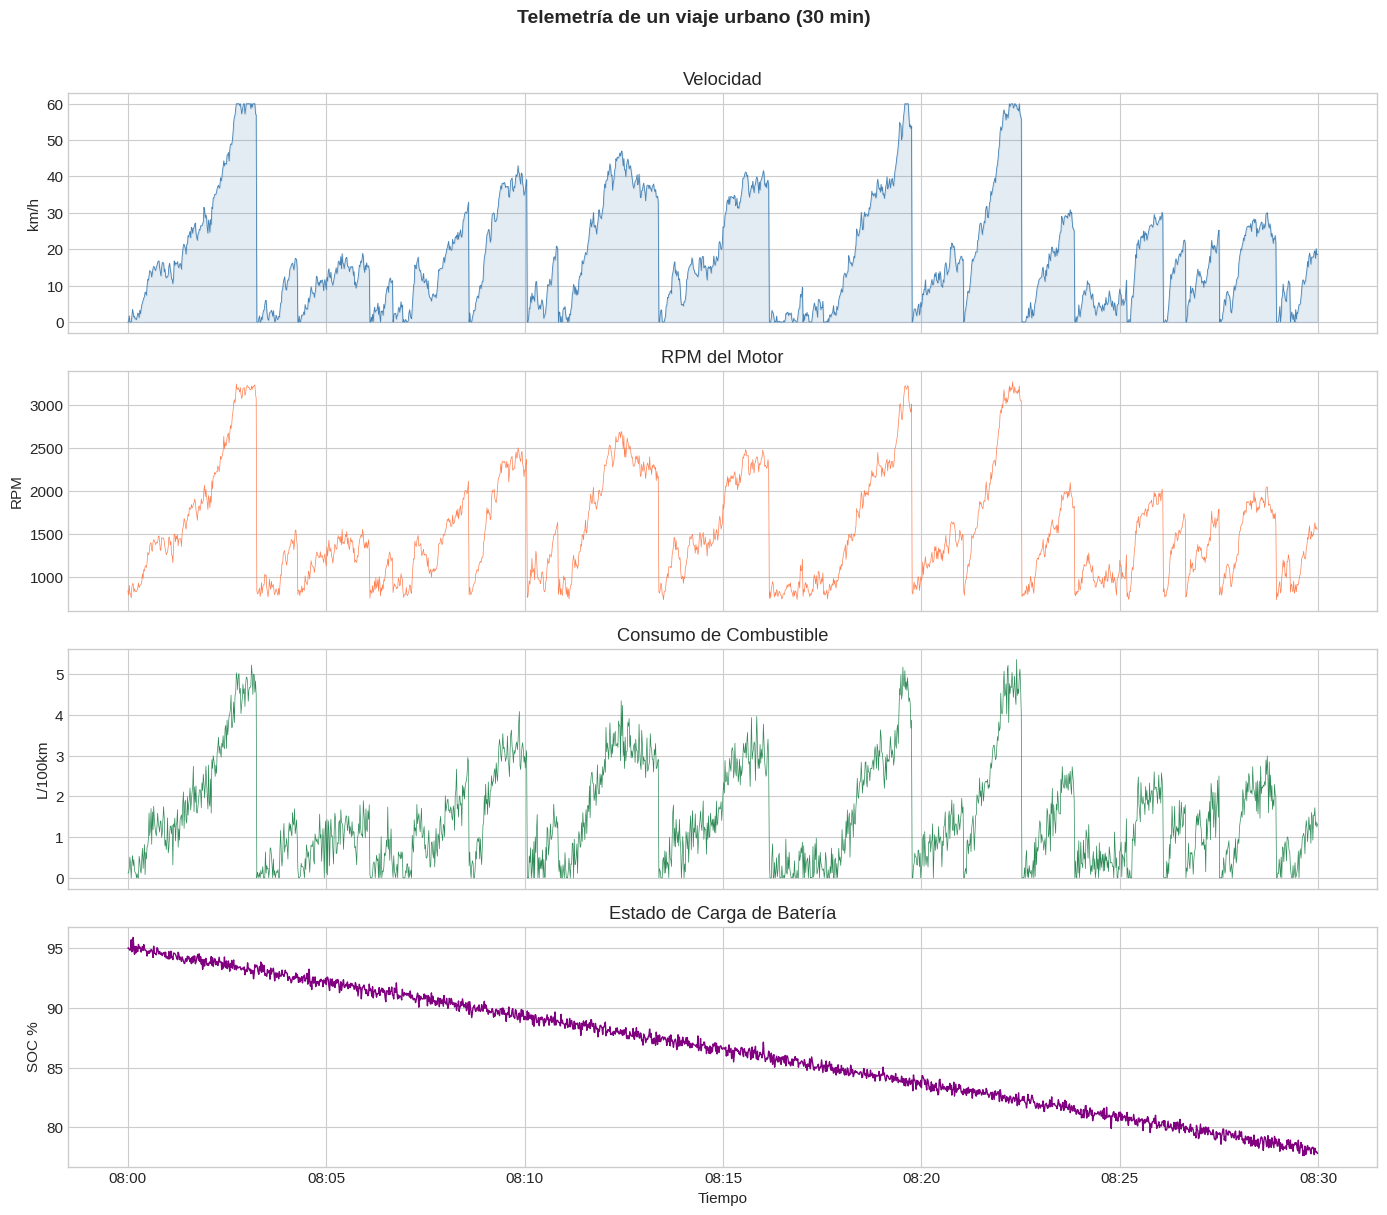

In [3]:
# Visualizar las señales del viaje
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(df.index, df['speed_kmh'], linewidth=0.6, color='steelblue')
axes[0].fill_between(df.index, df['speed_kmh'], alpha=0.15, color='steelblue')
axes[0].set_ylabel('km/h')
axes[0].set_title('Velocidad')

axes[1].plot(df.index, df['motor_rpm'], linewidth=0.5, color='coral')
axes[1].set_ylabel('RPM')
axes[1].set_title('RPM del Motor')

axes[2].plot(df.index, df['fuel_consumption'], linewidth=0.5, color='seagreen')
axes[2].set_ylabel('L/100km')
axes[2].set_title('Consumo de Combustible')

axes[3].plot(df.index, df['battery_soc'], linewidth=1, color='purple')
axes[3].set_ylabel('SOC %')
axes[3].set_title('Estado de Carga de Batería')
axes[3].set_xlabel('Tiempo')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

fig.suptitle('Telemetría de un viaje urbano (30 min)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [4]:
df.describe()

,speed_kmh,motor_rpm,fuel_consumption,battery_soc,battery_temp_c,gps_lat,gps_lon
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,18.566506,1542.220556,1.513981,86.496922,28.747278,19.432363,-99.133099
std,15.391414,616.081448,1.246137,4.913085,2.290695,0.000213,0.000131
min,0.000000,739.000000,0.000000,77.610000,24.500000,19.431916,-99.133394
25%,5.740000,1031.000000,0.491500,82.287500,26.700000,19.432259,-99.133209
50%,14.945000,1396.500000,1.237000,86.580000,28.700000,19.432362,-99.133115
75%,28.032500,1922.750000,2.336250,90.752500,30.700000,19.432493,-99.133000
max,60.000000,3265.000000,5.363000,95.910000,33.100000,19.432851,-99.132767


## 2. Indexación temporal y filtrado

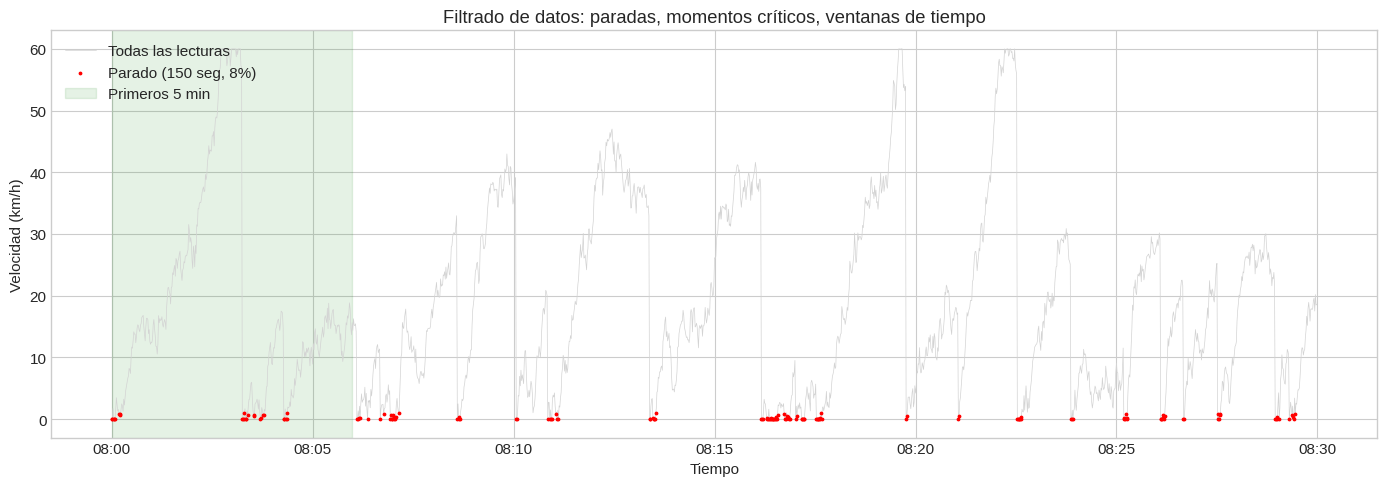

In [5]:
# Seleccionar primeros 5 minutos y filtrar por condición
primeros_5min = df.loc["2025-03-01 08:00":"2025-03-01 08:05"]
parado = df[df["speed_kmh"] < 1]
critico = df.query("speed_kmh > 50 and battery_soc < 80")

# Visualizar filtros
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['speed_kmh'], linewidth=0.5, color='lightgray', label='Todas las lecturas')
ax.scatter(parado.index, parado['speed_kmh'], color='red', s=3, label=f'Parado ({len(parado)} seg, {len(parado)/len(df)*100:.0f}%)', zorder=5)
if len(critico) > 0:
    ax.scatter(critico.index, critico['speed_kmh'], color='orange', s=10, marker='^',
               label=f'Crítico: vel>50 & SOC<80% ({len(critico)} seg)', zorder=6)
ax.axvspan(primeros_5min.index[0], primeros_5min.index[-1], alpha=0.1, color='green', label='Primeros 5 min')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Velocidad (km/h)')
ax.set_title('Filtrado de datos: paradas, momentos críticos, ventanas de tiempo')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 3. Agregación por ventanas de tiempo (resample)

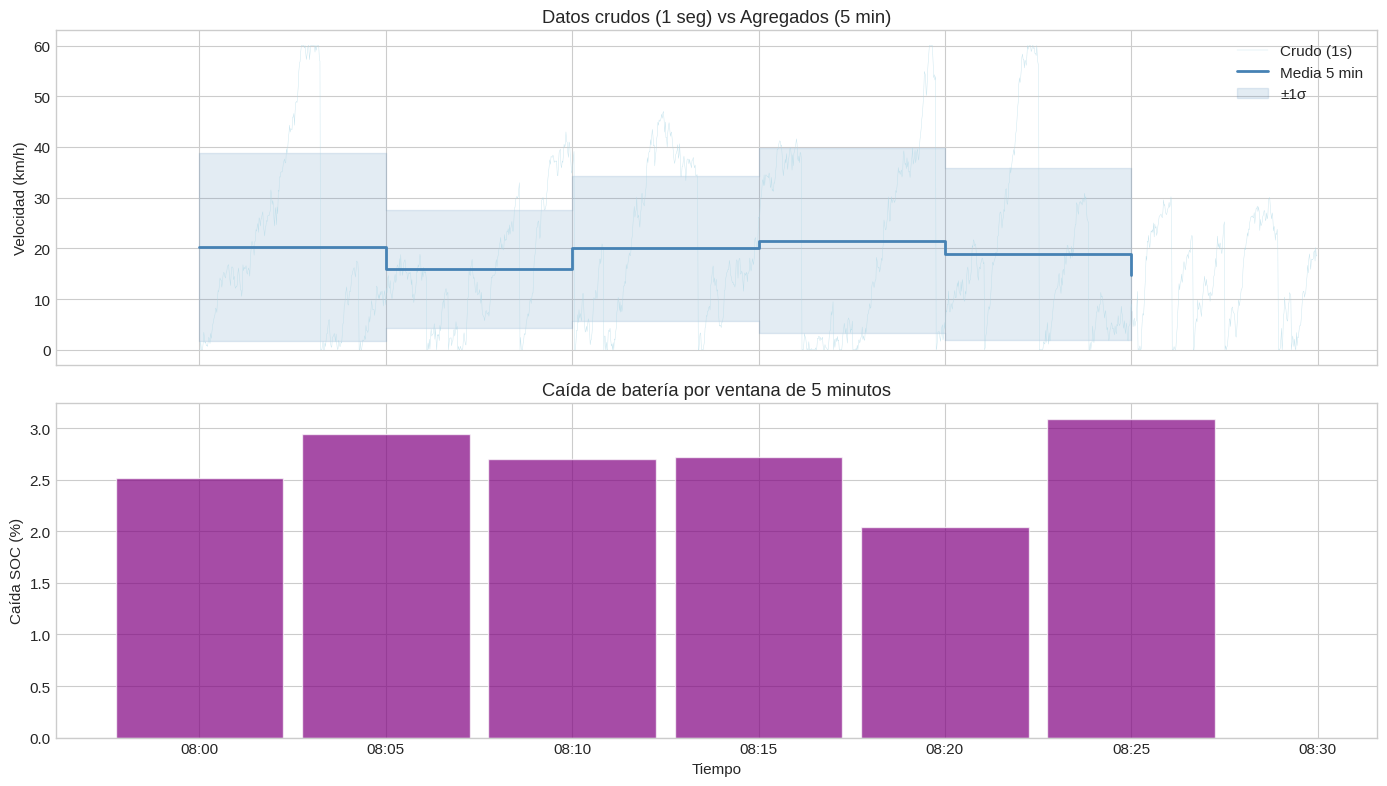

Tabla agregada:


,speed_kmh_mean,speed_kmh_max,speed_kmh_std,fuel_consumption_sum,battery_soc_first,battery_soc_last,battery_temp_c_max,motor_rpm_mean
timestamp,,,,,,,,
2025-03-01 08:00:00,20.231733,60.00,18.576887,493.572,95.01,92.49,26.5,1610.943333
2025-03-01 08:05:00,15.962333,42.97,11.560972,400.746,91.95,89.01,27.7,1436.146667
2025-03-01 08:10:00,20.028300,47.01,14.332118,482.303,89.24,86.54,29.3,1601.436667
2025-03-01 08:15:00,21.472100,60.00,18.248861,533.517,86.65,83.93,30.4,1658.606667
2025-03-01 08:20:00,18.953367,60.00,16.962287,453.280,83.30,81.26,31.7,1554.603333
2025-03-01 08:25:00,14.751200,30.18,9.245108,361.748,80.88,77.79,33.1,1391.586667


In [6]:
# Resample a ventanas de 5 minutos
df_5min = df.select_dtypes(include=[np.number]).resample("5min").agg({
    "speed_kmh": ["mean", "max", "std"],
    "fuel_consumption": "sum",
    "battery_soc": ["first", "last"],
    "battery_temp_c": "max",
    "motor_rpm": "mean",
})
df_5min.columns = ["_".join(col) for col in df_5min.columns]

# Visualizar agregado vs crudo
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Velocidad cruda vs media 5min
axes[0].plot(df.index, df['speed_kmh'], linewidth=0.3, color='lightblue', alpha=0.7, label='Crudo (1s)')
axes[0].step(df_5min.index, df_5min['speed_kmh_mean'], where='post',
             linewidth=2, color='steelblue', label='Media 5 min')
axes[0].fill_between(df_5min.index, df_5min['speed_kmh_mean'] - df_5min['speed_kmh_std'],
                     df_5min['speed_kmh_mean'] + df_5min['speed_kmh_std'],
                     alpha=0.15, color='steelblue', step='post', label='±1σ')
axes[0].set_ylabel('Velocidad (km/h)')
axes[0].set_title('Datos crudos (1 seg) vs Agregados (5 min)')
axes[0].legend()

# SOC por ventana
axes[1].bar(df_5min.index, df_5min['battery_soc_first'] - df_5min['battery_soc_last'],
            width=pd.Timedelta(minutes=4.5), color='purple', alpha=0.7, edgecolor='white')
axes[1].set_ylabel('Caída SOC (%)')
axes[1].set_title('Caída de batería por ventana de 5 minutos')
axes[1].set_xlabel('Tiempo')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.show()

print("Tabla agregada:")
df_5min

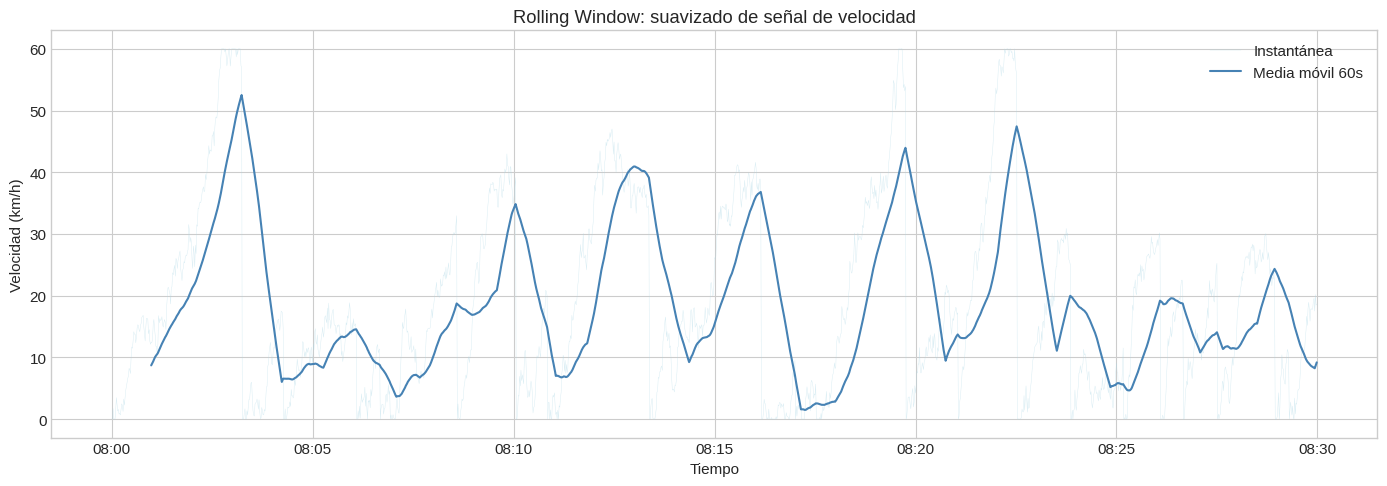

In [7]:
# Rolling window: media móvil de 1 minuto
df['speed_rolling_60s'] = df['speed_kmh'].rolling(window=60).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['speed_kmh'], linewidth=0.3, alpha=0.5, color='lightblue', label='Instantánea')
ax.plot(df.index, df['speed_rolling_60s'], linewidth=1.5, color='steelblue', label='Media móvil 60s')
ax.set_xlabel('Tiempo')
ax.set_ylabel('Velocidad (km/h)')
ax.set_title('Rolling Window: suavizado de señal de velocidad')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.legend()
plt.tight_layout()
plt.show()

df = df.drop(columns=['speed_rolling_60s'])

## 4. Múltiples vehículos: GroupBy

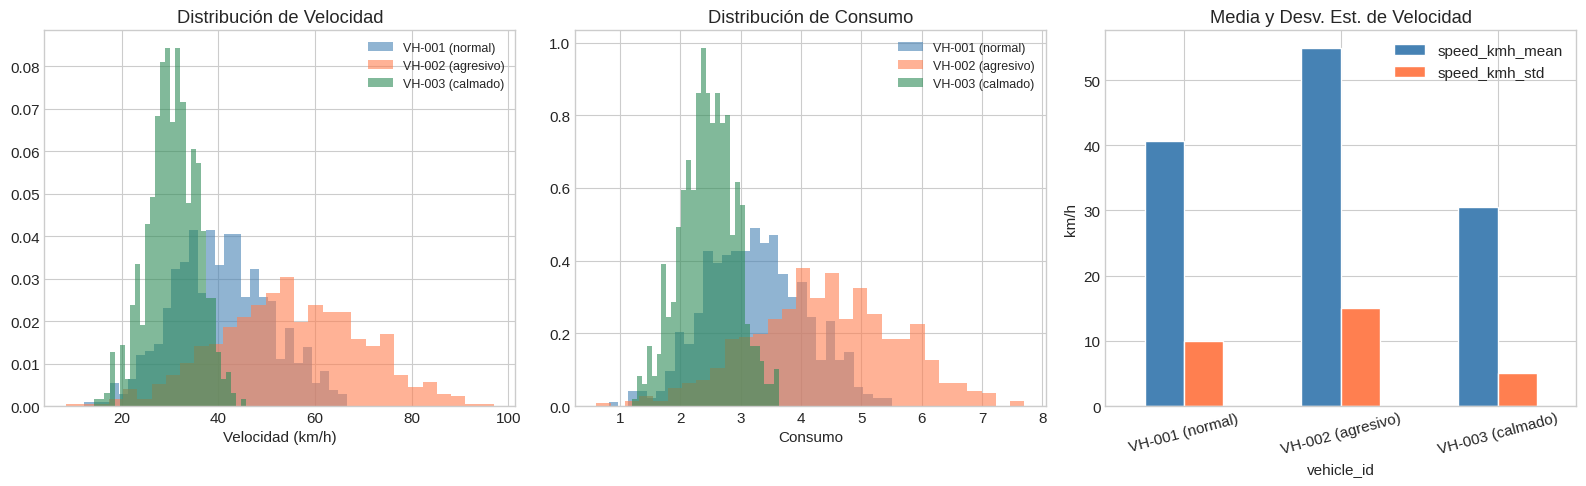

Estadísticas por vehículo:


,speed_kmh_mean,speed_kmh_max,speed_kmh_std,fuel_consumption_mean,fuel_consumption_sum
vehicle_id,,,,,
VH-001 (normal),40.647067,66.52,10.012050,3.248673,1949.204
VH-002 (agresivo),54.878583,97.01,14.963969,4.393163,2635.898
VH-003 (calmado),30.599800,45.79,5.107638,2.456218,1473.731


In [8]:
# Simular 3 vehículos con estilos distintos
vehiculos = []
estilos = {"VH-001 (normal)": (40, 10), "VH-002 (agresivo)": (55, 15), "VH-003 (calmado)": (30, 5)}

for vid, (speed_mean, speed_std) in estilos.items():
    n = 600
    ts = pd.date_range(start="2025-03-01 08:00", periods=n, freq="s")
    speed = np.clip(rng.normal(speed_mean, speed_std, n), 0, 120)
    vehiculos.append(pd.DataFrame({
        "vehicle_id": vid,
        "speed_kmh": np.round(speed, 2),
        "fuel_consumption": np.round(speed * 0.08 + rng.normal(0, 0.2, n), 3),
    }, index=ts))

df_multi = pd.concat(vehiculos)

# GroupBy stats
stats = df_multi.groupby("vehicle_id").agg({
    "speed_kmh": ["mean", "max", "std"],
    "fuel_consumption": ["mean", "sum"],
})
stats.columns = ["_".join(col) for col in stats.columns]

# Visualizar comparación
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['steelblue', 'coral', 'seagreen']

for i, (vid, group) in enumerate(df_multi.groupby("vehicle_id")):
    axes[0].hist(group['speed_kmh'], bins=30, alpha=0.6, color=colors[i], label=vid, density=True)
    axes[1].hist(group['fuel_consumption'], bins=30, alpha=0.6, color=colors[i], label=vid, density=True)

axes[0].set_xlabel('Velocidad (km/h)')
axes[0].set_title('Distribución de Velocidad')
axes[0].legend(fontsize=9)

axes[1].set_xlabel('Consumo')
axes[1].set_title('Distribución de Consumo')
axes[1].legend(fontsize=9)

# Bar chart con stats
stats_plot = stats[['speed_kmh_mean', 'speed_kmh_std']]
stats_plot.plot(kind='bar', ax=axes[2], color=['steelblue', 'coral'], edgecolor='white')
axes[2].set_title('Media y Desv. Est. de Velocidad')
axes[2].set_ylabel('km/h')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("Estadísticas por vehículo:")
stats

## 5. Merge/Join: Unir telemetría con información del vehículo

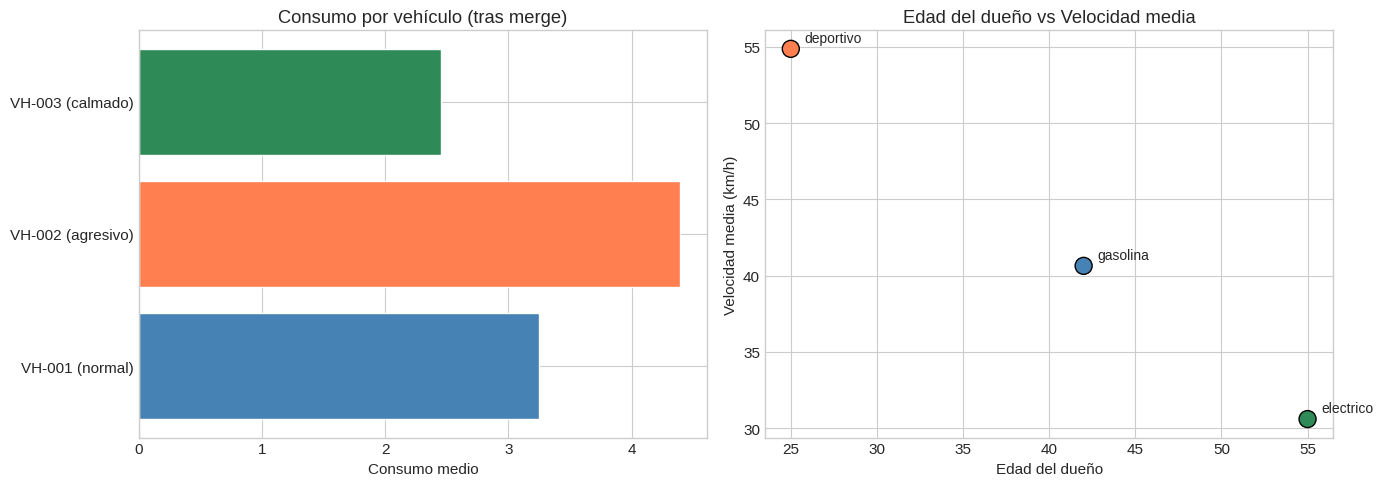

Resultado del merge:


,vehicle_id,vehicle_type,model_year,owner_age,speed_kmh_mean,speed_kmh_max,speed_kmh_std,fuel_consumption_mean,fuel_consumption_sum
0,VH-001 (normal),gasolina,2022,42,40.647067,66.52,10.012050,3.248673,1949.204
1,VH-002 (agresivo),deportivo,2023,25,54.878583,97.01,14.963969,4.393163,2635.898
2,VH-003 (calmado),electrico,2024,55,30.599800,45.79,5.107638,2.456218,1473.731


In [9]:
# Tabla maestra
vehiculos_maestro = pd.DataFrame({
    "vehicle_id": ["VH-001 (normal)", "VH-002 (agresivo)", "VH-003 (calmado)"],
    "vehicle_type": ["gasolina", "deportivo", "electrico"],
    "model_year": [2022, 2023, 2024],
    "owner_age": [42, 25, 55],
})

# Merge
resultado = vehiculos_maestro.merge(stats, on="vehicle_id")

# Visualizar: scatter consumo vs edad del dueño
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(resultado['vehicle_id'], resultado['fuel_consumption_mean'], color=colors, edgecolor='white')
axes[0].set_xlabel('Consumo medio')
axes[0].set_title('Consumo por vehículo (tras merge)')

axes[1].scatter(resultado['owner_age'], resultado['speed_kmh_mean'], s=150, c=colors, edgecolors='black', zorder=5)
for _, row in resultado.iterrows():
    axes[1].annotate(row['vehicle_type'], (row['owner_age'], row['speed_kmh_mean']),
                     textcoords='offset points', xytext=(10, 5), fontsize=10)
axes[1].set_xlabel('Edad del dueño')
axes[1].set_ylabel('Velocidad media (km/h)')
axes[1].set_title('Edad del dueño vs Velocidad media')

plt.tight_layout()
plt.show()

print("Resultado del merge:")
resultado

## 6. Datos faltantes (missing data)

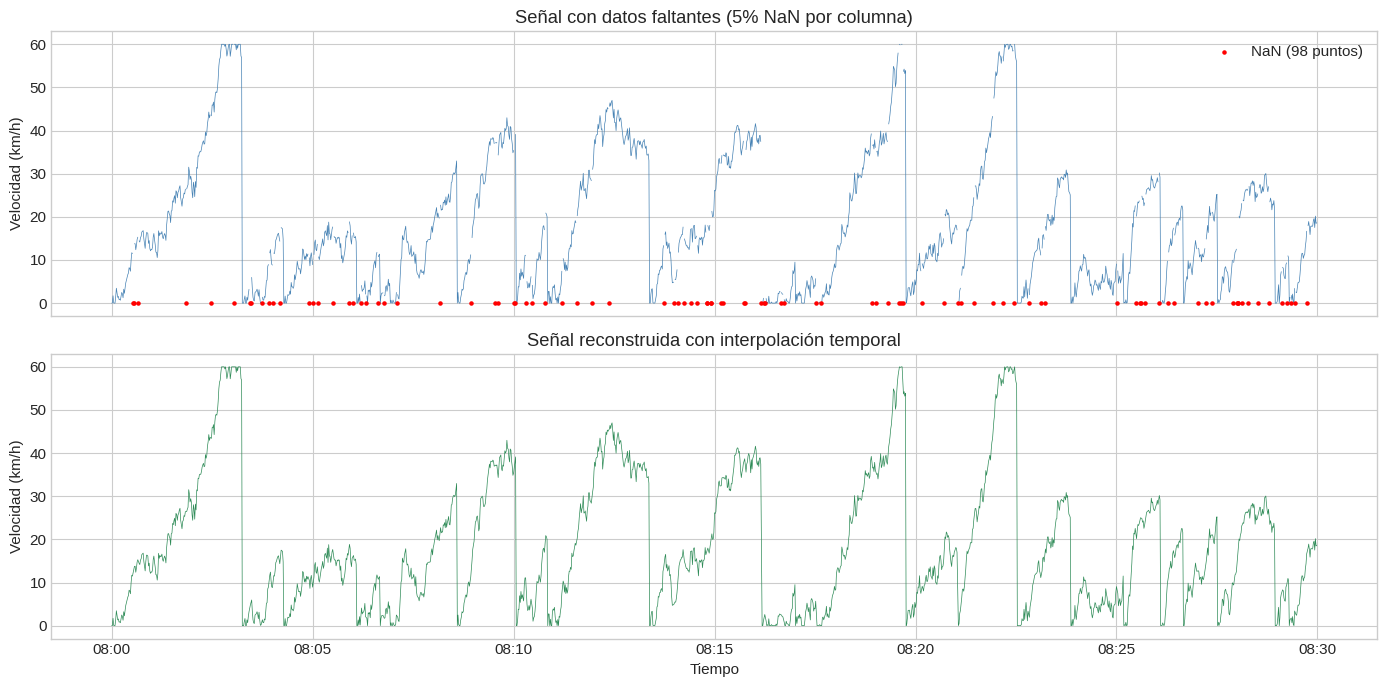

Valores faltantes antes/después:
  Antes: 275 NaN
  Después (interpolación): 0 NaN

→ Para sensores, la interpolación temporal es la mejor estrategia


In [10]:
# Simular sensor con fallas
df_missing = df[["speed_kmh", "fuel_consumption", "battery_soc"]].copy()
for col in df_missing.columns:
    mask = rng.random(len(df_missing)) < 0.05
    df_missing.loc[mask, col] = np.nan

# Estrategias
df_interpolated = df_missing.interpolate(method="time")

# Visualizar original vs interpolado
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

col = 'speed_kmh'
# Con NaN
axes[0].plot(df_missing.index, df_missing[col], linewidth=0.5, color='steelblue')
nan_mask = df_missing[col].isna()
axes[0].scatter(df_missing.index[nan_mask], [0]*nan_mask.sum(), color='red', s=5, zorder=5, label=f'NaN ({nan_mask.sum()} puntos)')
axes[0].set_ylabel('Velocidad (km/h)')
axes[0].set_title(f'Señal con datos faltantes (5% NaN por columna)')
axes[0].legend()

# Interpolado
axes[1].plot(df_interpolated.index, df_interpolated[col], linewidth=0.5, color='seagreen')
axes[1].set_ylabel('Velocidad (km/h)')
axes[1].set_title('Señal reconstruida con interpolación temporal')
axes[1].set_xlabel('Tiempo')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.show()

print("Valores faltantes antes/después:")
print(f"  Antes: {df_missing.isnull().sum().sum()} NaN")
print(f"  Después (interpolación): {df_interpolated.isnull().sum().sum()} NaN")
print("\n→ Para sensores, la interpolación temporal es la mejor estrategia")

## Resumen y conclusiones

### Lo que aprendimos:
1. **DataFrames** organizan datos tabulares con índices temporales
2. **resample** y **rolling** agregan datos en ventanas temporales
3. **groupby** calcula métricas por grupo (vehículo, tipo, etc.)
4. **merge/join** cruza diferentes fuentes de datos
5. La **interpolación temporal** es ideal para datos faltantes de sensores

### Respuesta a la pregunta de negocio:
> **¿Cómo organizamos datos multi-sensor de un viaje?**
>
> Un DataFrame con DatetimeIndex, una fila por segundo, una columna por sensor.
> Agregamos con resample (ventanas), analizamos con groupby (por vehículo),
> y cruzamos con merge (telemetría + perfil del comprador).

### Siguiente notebook:
→ `03_vehicle_simulator.ipynb`: Construir el simulador completo